# Main — Wrap the 0.01 (fair-anchored volume farm)

The endgame strategy, built on everything learned in `signal.ipynb`: the 0.01 player is an
unranked cross-venue MM that pins a one-sided 0.01 quote to the **Coinbase mid** (ask when
CB is above the TM mid, bid when below), repricing within ~1.5s. Maker fee is **0 bps**,
taker is **4 bps**, and maker volume scores **5x** in the competition.

## The three plays, in priority order

1. **Stale-0.01 snipe** — their cancel path fails sometimes and leaves an abandoned 0.01
   resting while CB drifts away. Any exact-0.01 level mispriced ≥ `STALE_MIN_EDGE_USD`
   against CB is free money: take it in clips (real PnL, and they're unranked so the 5x
   maker credit it pays them is competitively irrelevant).
2. **Fair-front quoting** (peg or no peg) — both sides, always as close to the front of
   the book as fair allows: `bid = min(CB − 1 tick, best_ask − 1 tick)`,
   `ask = max(CB + 1 tick, best_bid + 1 tick)`, **strictly passive** (capped inside the
   opposite touch, refused at send time if it would still cross). The lesson of the
   zero-volume session: on a thin venue, fills only happen at the touch — a perfectly
   fair-priced quote buried behind the dust and the peg never trades. So we undercut
   anything quoting outside CB fair (the peg included), keep ≥1 tick of edge, and stand
   back to fair rather than overpay when a side is already inside it. With the peg pinned
   at fair this converges to the 1-tick lock — our quotes one tick either side of the
   peg, in front of it, with the dust relegated to joining behind us in queue. Dust is
   never swept: taking it pays ranked competitors 5x and us 1x plus 4 bps.
3. **Peg churn** (`PEG_CHURN`) — manufactured taker volume against the unranked 0.01, on
   a slow clock: take a clip at their exact price (~zero edge loss, they sit AT fair).
   We get 1x credit, a player who isn't on the leaderboard gets the 5x, the dust gets
   **nothing** — the take fires only when the peg is the effective front of its side, so
   a marketable limit can never sweep ranked competitors on the way in. 4 bps fees run
   inside a hard session budget (`CHURN_FEE_BUDGET_USD`); past it, churn stops and the
   maker business continues. Churn doubles as inventory recycling, keeping the quotes
   from standing down at the band.

Inventory is band-managed: quotes stop at `MAX_POSITION_BTC`, and at the band we **unwind
through the live peg** at fair (4 bps, no points leaked — they're unranked), which keeps
the wrap quoting continuously instead of standing down.

## The one safety invariant

Quotes are **maker by construction** — targets are capped inside the opposite touch and a
send-time cross guard refuses anything that would still take, so a quote can never pay
taker fees or feed a ranked competitor (and the maker/taker split on the chart is
trustworthy: fees only ever come from labelled TAKER events). The only deliberate takes
are stale snipes, band unwinds and peg churn — all against the unranked 0.01 player, and
all protected by a **front-of-book guard**: the take fires only when its target is the
first order in line (netted of our own quote, which is confirm-cancelled first when it
sits in front), so a marketable limit can never sweep dust on the way to the peg. Because
those takes exist, plain "never take" is replaced by one invariant, re-validated inside
the single order path (`place_active_limit`) at the last instant before every HTTP call:

> **Never buy above CB fair + `FAIR_TOL_TICKS`, never sell below CB fair − `FAIR_TOL_TICKS`.**

Every fill this bot can possibly produce is at-or-better than Coinbase fair ± $1.20 —
worst case ~$0.001 on a 0.001 clip — regardless of what the TM book does in flight.
Supporting gates: both feeds fresh (a stale Coinbase feed pulls all quotes immediately —
quoting off dead fair is the one fatal failure mode), TM-vs-CB 1% sanity bound,
crossed-book gate, rate-limit reserve + soft throttle, cancel-confirm before every
replace, ghost-order verification, per-side reprice cooldown + hysteresis (quotes follow
the anchor but don't chase every CB tick — chasing would burn the rate budget for
fractions of a cent of protection), safety pull with **no** cooldown when CB moves
`SAFETY_PULL_USD` ($2) through a resting quote, $ loss-limit kill switch marked to CB
fair, and cancel-all on every exit path.

## Economics (why this wins)

- Wrap round trip (both quotes fill): earn the 2-tick spread, **0 fees**, credit =
  `5 × 2 × notional`. The only loss channel is adverse selection when CB jumps faster
  than our reprice — bounded by clip size, mitigated by the safety pull.
- Stale snipe: pure PnL ≥ $30/BTC-clip by construction, minus 4 bps.
- Unwind: 4 bps on a clip at fair, buys back quote-room on both sides.
- Score telemetry: `score = 5 × maker + 1 × taker` with estimated fees, live on the chart.
  (Maker/taker split is approximated locally — a wrap quote that part-sweeps then rests
  books its later fills as maker via balance deltas; the exchange's official count is
  authoritative.)

## Sizing (full ~$1,100 portfolio deployment)
`CLIP_BTC = 0.002` (~$130 per quote → $640 credit per maker fill, 40–500x what a dust
fill earns the leader), band `MAX_POSITION_BTC = 0.006` (~$385 ≈ 35% of portfolio),
`DAILY_LOSS_LIMIT = $15`. The cash side funds ~7 clips; a **one-time startup rebalance**
market-buys BTC up to `REBALANCE_BTC_TARGET = 0.008` (band + one clip, ~$400 at ~4bps,
once) so the ask side is funded symmetrically — it runs before the PnL baseline is
snapped, so it doesn't count against the loss limit. Expect that buy in the log at
startup; it is intentional.

In [31]:
import sys
import os
import asyncio
import math
import time
import json
from pathlib import Path

ROOT_DIR = Path(os.getcwd()).parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import aiohttp
import websockets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from dotenv import load_dotenv

from lib.execution import ExecutionClient

load_dotenv(ROOT_DIR / 'keys' / '.env')

TM_REST_URL = os.getenv('BASE_REST_URL', 'https://api.truemarkets.co')
TM_KEY_FILE = str(ROOT_DIR / 'keys' / 'truemarkets-api-key-edd1691b.json')
CB_WS_URL   = os.getenv('COINBASE_WS_URL', 'wss://ws-feed.exchange.coinbase.com')
CB_PRODUCT  = 'BTC-USD'
BASE_ASSET  = 'BTC'
QUOTE_ASSET = 'USDC'


In [32]:
class TrueMarketsBook:
    _WS_URL = 'wss://api.truex.co/api/v1'
    _HEADERS = {
        'Origin': 'https://truemarkets.co',
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36',
        'Accept-Language': 'en-US,en;q=0.9',
    }

    def __init__(self, symbol='BTC-PYUSD'):
        self.symbol    = symbol
        self._bids     = {}
        self._asks     = {}
        self._ready    = False
        self._last_msg = None            # wall-clock time of last websocket message
        self.updated   = asyncio.Event() # set on every book change — lets the strategy react instantly

    @property
    def best_bid(self):      return max(self._bids) if self._bids else None
    @property
    def best_ask(self):      return min(self._asks) if self._asks else None
    @property
    def mid(self):
        b, a = self.best_bid, self.best_ask
        return (b + a) / 2.0 if (b is not None and a is not None) else None
    @property
    def is_ready(self): return self._ready
    @property
    def age(self):
        """Seconds since the last websocket message, or None if never connected."""
        return (time.time() - self._last_msg) if self._last_msg else None

    def _handle_snapshot(self, data):
        self._bids  = {float(b['price']): float(b['qty']) for b in data.get('bids', []) if float(b['qty']) > 0}
        self._asks  = {float(a['price']): float(a['qty']) for a in data.get('asks', []) if float(a['qty']) > 0}
        self._ready = True
        self.updated.set()

    def _handle_update(self, data):
        for b in data.get('bids', []):
            p, q = float(b['price']), float(b['qty'])
            if q == 0: self._bids.pop(p, None)
            else:      self._bids[p] = q
        for a in data.get('asks', []):
            p, q = float(a['price']), float(a['qty'])
            if q == 0: self._asks.pop(p, None)
            else:      self._asks[p] = q
        self.updated.set()

    async def run(self):
        backoff = 1
        while True:
            try:
                async with websockets.connect(self._WS_URL, additional_headers=self._HEADERS) as ws:
                    backoff = 1
                    self._ready = False
                    await ws.send(json.dumps({
                        'type': 'SUBSCRIBE_NO_AUTH',
                        'item_names': [self.symbol],
                        'channels': ['DEPTH'],
                        'timestamp': str(int(time.time())),
                    }))
                    async for raw in ws:
                        self._last_msg = time.time()
                        try: msg = json.loads(raw)
                        except Exception: continue
                        t = msg.get('update')
                        d = msg.get('data', {})
                        if   t == 'SNAPSHOT': self._handle_snapshot(d)
                        elif t == 'UPDATE':   self._handle_update(d)
            except websockets.ConnectionClosed:
                pass
            except Exception as e:
                print(f'TrueMarketsBook error: {e}')
            self._ready = False
            self.updated.set()   # wake the strategy so it notices the outage immediately
            await asyncio.sleep(backoff)
            backoff = min(backoff * 2, 30)


class CoinbaseFeed:
    """Coinbase best bid/ask (ticker channel) — THE fair price everything is
    anchored to. If this goes stale the strategy pulls every quote immediately."""

    def __init__(self, url=CB_WS_URL, product=CB_PRODUCT):
        self.url      = url
        self.product  = product
        self.bid      = None
        self.ask      = None
        self.last_msg = None

    @property
    def mid(self):
        return (self.bid + self.ask) / 2 if (self.bid and self.ask) else None

    @property
    def fresh(self):
        return self.last_msg is not None and time.time() - self.last_msg <= CB_MAX_AGE_SECS

    async def run(self):
        backoff = 1
        while True:
            try:
                async with websockets.connect(self.url) as ws:
                    backoff = 1
                    await ws.send(json.dumps({
                        'type': 'subscribe',
                        'product_ids': [self.product],
                        'channels': ['ticker'],
                    }))
                    async for raw in ws:
                        try: m = json.loads(raw)
                        except Exception: continue
                        if m.get('type') == 'ticker':
                            b, a = m.get('best_bid'), m.get('best_ask')
                            if b and a:
                                self.bid, self.ask = float(b), float(a)
                                self.last_msg = time.time()
            except asyncio.CancelledError:
                raise
            except Exception as e:
                print(f'Coinbase feed error: {e}')
            await asyncio.sleep(backoff)
            backoff = min(backoff * 2, 30)

### Parameters

In [33]:
# ── sizes / risk (sized to the full ~$1,100 competition portfolio) ───────────
CLIP_BTC           = 0.002   # EVERY order is exactly this size (~$130/quote → $640 credit
                             # per maker fill at 5x). Cash funds ~7 clips; the startup
                             # rebalance below funds the BTC side symmetrically
TRIGGER_SIZE_BTC   = 0.01    # the player we anchor to / exploit
SIZE_EPS           = 1e-9
MAX_POSITION_BTC   = 0.006   # hard inventory band (~$385 ≈ 35% of portfolio); at the band
                             # we unwind through the peg
DAILY_LOSS_LIMIT   = 25.0    # session kill switch ($, marked to CB fair). Includes the
                             # $10 churn fee budget below — past it, an assumption broke

# ── peg churn: manufactured taker volume against the unranked 0.01 ───────────
PEG_CHURN            = True   # take a clip from the peg on a slow clock: 1x credit to us,
                              # 5x to a player who isn't on the leaderboard, zero to dust
                              # (front-of-book guard), ~zero edge (they sit AT fair), 4bps
CHURN_MIN_SECS       = 30.0   # pace: ~$15k notional/hour ≈ $6/hour in fees at 0.002 clips
CHURN_FEE_BUDGET_USD = 10.0   # stop churning past this spend; maker business continues

# ── startup inventory rebalance ──────────────────────────────────────────────
REBALANCE_BTC_TARGET = 0.008  # market-buy up to this at start so the ask side is funded
                              # (band + one clip). One-time ~4bps taker fee on ~$400,
                              # done BEFORE the PnL baseline so it doesn't hit the limit
REBALANCE_MIN_BTC    = 0.001  # skip the rebalance if already within this of target

TICK_SIZE          = 0.1
PRICE_DECIMALS     = 1
IDLE_TICK_SECS     = 0.25    # heartbeat — also how fast we notice pure-CB moves

# ── the core invariant ───────────────────────────────────────────────────────
FAIR_TOL_TICKS     = 12      # never buy above CB fair + this, never sell below fair − this
                             # ($1.20 — must exceed PEG_NEAR_USD or wrap quotes around an
                             # offset peg self-refuse; worst-case cost ≈ $1.2 × 0.001 clip)
SAFETY_PULL_USD    = 2.0     # CB moving this far THROUGH a resting quote pulls it instantly
                             # (no cooldown). Tick-level jitter is left to normal repricing —
                             # pulling on every $0.1 CB wiggle would burn the rate budget for
                             # ~$0.0002/clip of protection

# ── peg / stale detection ────────────────────────────────────────────────────
PEG_NEAR_USD       = 1.0     # exact-0.01 level within this of CB mid = the live peg
STALE_MIN_EDGE_USD = 30.0    # exact-0.01 level mispriced vs CB by this much = snipe it
                             # (must clear 4bps taker fee ≈ $26/BTC at $64k, plus buffer)

# ── quoting cadence / rate-limit protection ──────────────────────────────────
QUOTE_EDGE_TICKS   = 1       # quotes keep at least this much edge vs CB fair
REPRICE_HYST_TICKS = 3       # don't chase the anchor until the quote is this far off
REPRICE_MIN_SECS   = 5.0     # per-side cancel/replace cooldown (safety pulls exempt).
                             # steady-state worst case: 2 sides × 2 req / 5s = 48 req/min,
                             # leaving room for balance polls, takes and ghost checks
RL_RESERVE         = 8       # hard reserve: no new orders below this
RL_SOFT            = 35      # soft throttle: below this only safety pulls / critical work

# ── take management ──────────────────────────────────────────────────────────
TAKE_COOLDOWN_SECS = 2.0
TAKE_TIMEOUT_SECS  = 3.0     # unfilled take is cancelled after this — never chase
FILL_CHECK_SECS    = 0.8

# ── feed safety ──────────────────────────────────────────────────────────────
MAX_BOOK_AGE_SECS  = 5.0     # TM book stale -> no new orders
PULL_QUOTES_AFTER_SECS = 10.0  # TM book dead this long -> pull quotes
CB_MAX_AGE_SECS    = 5.0     # CB feed stale -> pull ALL quotes immediately (fatal mode).
                             # ticker only sends on trades; BTC-USD gaps >5s are rare
MAX_CB_DEVIATION   = 0.01    # TM mid vs CB mid sanity bound (1%)

# ── housekeeping ─────────────────────────────────────────────────────────────
BALANCE_POLL_SECS  = 5.0
SETTLE_GRACE_SECS  = 20.0    # after a booked take, balance-residual attribution waits
                             # this long — the balances endpoint lags fills by seconds,
                             # and booking the lag as maker fills invents volume twice
ORDER_VERIFY_SECS  = 60.0
GHOST_GRACE_SECS   = 3.0
GHOST_CHECK_MIN_SECS = 5.0
PLOT_EVERY_SECS    = 5.0
STATUS_EVERY_SECS  = 1.0
TM_BOOK_SYMBOL     = 'BTC-PYUSD'

# ── scoring telemetry ────────────────────────────────────────────────────────
MAKER_MULT         = 5.0
TAKER_FEE_BPS      = 4.0

LIVE_STATUSES = {'pending', 'active', 'open', 'new', 'partially_filled'}

### Helpers

In [34]:
clip_str = f'{CLIP_BTC:.8f}'.rstrip('0').rstrip('.')
assert clip_str == '0.002', f'clip must be exactly 0.002, got {clip_str}'

def fmt_px(p): return f'{p:.{PRICE_DECIMALS}f}'

def floor_tick(p): return math.floor(p / TICK_SIZE + 1e-9) * TICK_SIZE
def ceil_tick(p):  return math.ceil (p / TICK_SIZE - 1e-9) * TICK_SIZE
def round_tick(p): return round(p / TICK_SIZE) * TICK_SIZE

def is_trigger(sz):
    """True when a displayed size is EXACTLY 0.01."""
    return sz is not None and abs(sz - TRIGGER_SIZE_BTC) < SIZE_EPS

def levels_ex_own(levels, own_px=None, own_sz=0.0, reverse=False):
    """Book side as sorted (price, size) with our own resting order netted out —
    what the market looks like without us. Since our clip (0.001) never equals
    the trigger (0.01), netting can't fabricate or destroy a real 0.01 signal;
    it only removes our own contribution from a shared level."""
    out = []
    for p, q in levels.items():
        if own_px is not None and abs(p - own_px) < 1e-9:
            q -= own_sz
            if q < SIZE_EPS:
                continue
        out.append((p, q))
    out.sort(reverse=reverse)
    return out

def detect_levels(ask_lvls, bid_lvls, cb_mid):
    """Scan the netted book for exact-0.01 levels and classify them.

    Returns (peg_side, peg_px, stale_side, stale_px, stale_edge):
      peg   — the live anchor: the 0.01 nearest CB mid, within PEG_NEAR_USD
      stale — the best exploit: a 0.01 mispriced vs CB by >= STALE_MIN_EDGE_USD
              (an abandoned order from their broken cancel path). stale_side is
              how WE exploit it: 'sell' into a stale bid above fair, 'buy' a
              stale ask below fair."""
    if cb_mid is None:
        return None, None, None, None, 0.0
    peg_side = peg_px = stale_side = stale_px = None
    best_near = None
    stale_edge = 0.0
    for side, lvls in (('ask', ask_lvls), ('bid', bid_lvls)):
        for p, q in lvls:
            if not is_trigger(q):
                continue
            d = abs(p - cb_mid)
            if d <= PEG_NEAR_USD and (best_near is None or d < best_near):
                best_near, peg_side, peg_px = d, side, p
            edge = (p - cb_mid) if side == 'bid' else (cb_mid - p)
            if edge >= STALE_MIN_EDGE_USD and edge > stale_edge:
                stale_edge = edge
                stale_side = 'sell' if side == 'bid' else 'buy'
                stale_px   = p
    return peg_side, peg_px, stale_side, stale_px, stale_edge


async def cancel_confirmed(bot, session, oid):
    """True only when the order is CONFIRMED no longer live. A swallowed cancel
    failure must never free a slot — that is how duplicates happen."""
    if not oid:
        return True
    try:
        if await bot.cancel_order(session, oid):
            return True
    except Exception:
        pass
    try:
        st = await bot.get_order_status(session, oid)
    except Exception:
        return False
    if st is None:
        return False
    return st not in LIVE_STATUSES


async def place_active_limit(bot, session, tm_book, cb_feed, side, px,
                             expect_level=False, may_take=False, own_px=None):
    """The ONLY order-placement path. Quotes (may_take=False, the default) are
    maker by construction: anything that could cross the touch is refused, so
    a quote can never pay taker fees or hand 5x credit to a ranked competitor.
    Deliberate takes (may_take=True: stale snipes, band unwinds — both against
    the unranked 0.01 player) skip that guard but still obey the strategy's
    core invariant, re-validated here at the last instant before the HTTP call:

        never BUY above CB fair + FAIR_TOL_TICKS
        never SELL below CB fair − FAIR_TOL_TICKS

    Every fill this can produce is at-or-better than Coinbase fair. Anything
    that can't be verified against live, fresh feeds is refused.

    expect_level=True (snipes/unwinds): additionally require the target price
    level to still display at least one clip of size.

    Returns (order, refusal_reason) — exactly one of the two is set."""
    if abs(CLIP_BTC - 0.002) > 1e-12:
        return None, 'clip drifted from 0.002'
    if side not in ('buy', 'sell'):
        return None, f'bad side {side!r}'
    if abs(px - round_tick(px)) > 1e-6:
        return None, f'price {px} not tick-aligned'
    px_str = fmt_px(px)
    if abs(float(px_str) - px) > 1e-6:
        return None, f'price string {px_str} != {px}'
    if not tm_book.is_ready or tm_book.age is None or tm_book.age > MAX_BOOK_AGE_SECS:
        return None, 'TM book stale at send time'
    if not cb_feed.fresh or cb_feed.mid is None:
        return None, 'CB fair stale at send time'
    cb_mid = cb_feed.mid
    tol = FAIR_TOL_TICKS * TICK_SIZE
    if side == 'buy' and px > cb_mid + tol + 1e-9:
        return None, f'INVARIANT: buy {px_str} above fair {cb_mid:.1f}+{tol:.1f}'
    if side == 'sell' and px < cb_mid - tol - 1e-9:
        return None, f'INVARIANT: sell {px_str} below fair {cb_mid:.1f}-{tol:.1f}'
    lb, la = tm_book.best_bid, tm_book.best_ask
    if lb is None or la is None or lb >= la:
        return None, 'TM book empty/crossed at send time'
    if not may_take:
        # passive-only quote: if it can't rest, it must not be sent. Taking the
        # dust in front of the peg pays ranked competitors 5x credit and us 1x
        # plus 4bps — the quote engine caps targets inside the touch, and this
        # is the send-time backstop against the book moving in flight.
        if side == 'buy' and px > la - TICK_SIZE + 1e-9:
            return None, f'would take: bid {px_str} vs ask {la:.1f}'
        if side == 'sell' and px < lb + TICK_SIZE - 1e-9:
            return None, f'would take: ask {px_str} vs bid {lb:.1f}'
    else:
        # FRONT-OF-BOOK guard: a deliberate take must hit ONLY its target. A
        # marketable limit fills everything priced better first, so if any
        # order rests in front of the target (dust!), refuse — ranked
        # competitors never get a crumb of our taker flow. own_px nets out our
        # own just-cancelled quote, which the lagging feed may still display.
        if side == 'buy':
            lv = levels_ex_own(tm_book._asks, own_px, CLIP_BTC)
            front = lv[0][0] if lv else None
        else:
            lv = levels_ex_own(tm_book._bids, own_px, CLIP_BTC, reverse=True)
            front = lv[0][0] if lv else None
        if front is None or abs(front - px) > 1e-9:
            return None, f'not front of book (front={front}, target={px_str})'
    if expect_level:
        book = tm_book._asks if side == 'buy' else tm_book._bids
        q = book.get(px)
        if q is None or q < CLIP_BTC - 1e-9:
            return None, f'target level {px_str} gone'
    order = await bot.place_order(
        session, BASE_ASSET, QUOTE_ASSET,
        side, clip_str, 'base', 'limit', px_str
    )
    return order, None


async def get_full_balances(bot, session):
    data = await bot._get(session, '/v1/conductor/balances')
    total_btc = avail_btc = total_usd = avail_usd = 0.0
    if not data:
        return None, None, None, None
    for b in data.get('data', []):
        sym   = b.get('symbol', '')
        avail = float(b.get('available', 0) or 0)
        held  = float(b.get('held',      0) or 0)
        if sym == BASE_ASSET:
            total_btc += avail + held
            avail_btc += avail
        elif sym in (QUOTE_ASSET, 'PYUSD'):
            total_usd += avail + held
            avail_usd += avail
    return total_btc, total_usd, avail_btc, avail_usd

# ── chart series ─────────────────────────────────────────────────────────────
ts_s      = []
tm_mid_s  = []
cb_mid_s  = []
peg_px_s  = []
our_bid_s = []
our_ask_s = []
pnl_s     = []
score_s   = []
mvol_s    = []
tvol_s    = []
inv_s     = []
trades    = []   # (elapsed, side, px, label) — taker events only

def _cumsum(vals):
    out, s = [], 0.0
    for v in vals:
        s += v; out.append(s)
    return out

def _nan(x): return x if x is not None else float('nan')

def update_plot(tm_book=None, our_bid=None, our_ask=None, peg_px=None):
    clear_output(wait=True)
    fig, axes = plt.subplots(5, 1, figsize=(12, 20))
    ax0, ax1, ax2, ax3, ax4 = axes

    ax0.plot(ts_s, tm_mid_s, color='gray',        linewidth=1, label='TM mid', alpha=0.8)
    ax0.plot(ts_s, cb_mid_s, color='deepskyblue', linewidth=1, label='CB fair', alpha=0.8)
    ax0.scatter(ts_s, peg_px_s,  color='purple', s=6, label='0.01 peg', zorder=3)
    ax0.plot(ts_s, our_bid_s, color='lime',   linewidth=1, linestyle='--', label='our bid')
    ax0.plot(ts_s, our_ask_s, color='salmon', linewidth=1, linestyle='--', label='our ask')
    ax0.set_ylabel('Price ($)'); ax0.set_title('Anchor: peg / CB fair, and our wrap')
    ax0.legend(loc='upper left', fontsize=8, ncol=2); ax0.grid(True, alpha=0.3)

    ax1.plot(ts_s, pnl_s, color='green', label='Session PnL ($, marked to CB)')
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.axhline(-DAILY_LOSS_LIMIT, color='red', linestyle='--', linewidth=1,
                label=f'Loss limit -${DAILY_LOSS_LIMIT}')
    ax1.fill_between(ts_s, pnl_s, 0, where=[p >= 0 for p in pnl_s], alpha=0.15, color='green')
    ax1.fill_between(ts_s, pnl_s, 0, where=[p <  0 for p in pnl_s], alpha=0.15, color='red')
    ax1.set_ylabel('PnL ($)'); ax1.set_title('Session PnL')
    ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

    ax2.plot(ts_s, score_s, color='black', linewidth=2,
             label=f'Score = {MAKER_MULT:g}×maker + taker ($)')
    ax2.plot(ts_s, mvol_s, color='blue',   linewidth=1, label='Maker volume ($)')
    ax2.plot(ts_s, tvol_s, color='purple', linewidth=1, label='Taker volume ($)')
    ax2.set_ylabel('$'); ax2.set_title('Competition Score')
    ax2.legend(loc='upper left'); ax2.grid(True, alpha=0.3)

    ax3.plot(ts_s, inv_s, color='orange', label='Net inventory (BTC)')
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax3.axhline( MAX_POSITION_BTC, color='red', linestyle=':', alpha=0.6, label='Band')
    ax3.axhline(-MAX_POSITION_BTC, color='red', linestyle=':', alpha=0.6)
    buys  = [t for t, s, _, _ in trades if s == 'buy']
    sells = [t for t, s, _, _ in trades if s == 'sell']
    if buys:
        ax3.scatter(buys,  [CLIP_BTC]  * len(buys),  marker='^', color='green', s=50,
                    zorder=5, label='Taker buys')
    if sells:
        ax3.scatter(sells, [-CLIP_BTC] * len(sells), marker='v', color='red',   s=50,
                    zorder=5, label='Taker sells')
    ax3.set_ylabel('BTC'); ax3.set_title(f'Net Inventory — {len(trades)} taker events')
    ax3.legend(loc='upper left'); ax3.grid(True, alpha=0.3)

    if tm_book is not None and tm_book.is_ready and tm_book._bids and tm_book._asks:
        sorted_bids = sorted(tm_book._bids.items(), reverse=True)
        sorted_asks = sorted(tm_book._asks.items())
        bid_px  = [p for p, _ in sorted_bids]
        bid_cum = _cumsum([q for _, q in sorted_bids])
        ask_px  = [p for p, _ in sorted_asks]
        ask_cum = _cumsum([q for _, q in sorted_asks])
        ax4.fill_between(bid_px, bid_cum, step='post', color='green', alpha=0.35, label='Bids')
        ax4.plot(bid_px, bid_cum, color='lime',   drawstyle='steps-post', linewidth=1)
        ax4.fill_between(ask_px, ask_cum, step='pre',  color='red',   alpha=0.35, label='Asks')
        ax4.plot(ask_px, ask_cum, color='salmon', drawstyle='steps-pre',  linewidth=1)
        if our_bid is not None:
            ax4.axvline(our_bid, color='lime',   linestyle='--', linewidth=1.5,
                        label=f'Our bid ${our_bid:.1f}')
        if our_ask is not None:
            ax4.axvline(our_ask, color='salmon', linestyle='--', linewidth=1.5,
                        label=f'Our ask ${our_ask:.1f}')
        if peg_px is not None:
            ax4.axvline(peg_px, color='purple', linestyle=':', linewidth=2,
                        label=f'0.01 peg ${peg_px:.1f}')
        mid = (bid_px[0] + ask_px[0]) / 2
        ax4.set_xlim(mid - 500, mid + 500)
    else:
        ax4.text(0.5, 0.5, 'Waiting for order book...', ha='center', va='center',
                 transform=ax4.transAxes)
    ax4.set_xlabel('Price ($)'); ax4.set_ylabel('Cumulative BTC')
    ax4.set_title('Live TrueMarkets Order Book Depth')
    ax4.legend(loc='upper right'); ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

### Strategy Loop

Every websocket event (plus a 250ms heartbeat so pure-CB moves are caught fast):

| Step | What |
|---|---|
| 1 | Feed gates: CB stale → pull everything **immediately**; TM stale → stand down, pull after 10s |
| 2 | Sanity gates: crossed book, TM-vs-CB 1% deviation (pulls quotes), rate budget |
| 3 | Net our quotes out of the book → find the **peg** (0.01 within $1 of CB) and the best **stale 0.01** (mispriced ≥ $30 vs CB) |
| 4 | Targets = fair-front: `bid = min(CB − 1t, best_ask − 1t)`, `ask = max(CB + 1t, best_bid + 1t)` — front of each side, ≥1 tick edge vs fair, never through the opposite touch. Peg/mode kept for snipes, unwinds and display |
| 5 | Manage the single in-flight take (throttled polls, hard timeout) |
| 6 | Takes, one at a time: stale snipe first, else band unwind through the peg |
| 7 | Balance poll: **residual attribution** — measured position vs the local book. While a take is settling (< 20s old) a nonzero residual is deferred, never booked: the balances endpoint lags fills, and booking the lag invents a phantom maker fill twice |
| 8 | Ghost-order verification on resting quotes |
| 9 | Quote engine per side: hold on-target (queue priority) → **safety pull, no cooldown, when CB moves $2 through a quote** → reprice on ≥3-tick divergence with 5s cooldown → place **strictly passively** (targets capped inside the opposite touch; send-time cross guard; self-cross caps) |
| 10 | Chart / status / kill switch |

Quotes can never take: target capping plus the send-time cross guard make them maker by
construction, so fees only ever come from labelled TAKER events (stale snipes, unwinds,
or a loudly-flagged in-flight cross). Snipes/unwinds never cross our own quotes because
ours hug fair while stale targets are ≥ $30 away.

In [35]:
async def run_strategy():
    for s in [ts_s, tm_mid_s, cb_mid_s, peg_px_s, our_bid_s, our_ask_s,
              pnl_s, score_s, mvol_s, tvol_s, inv_s]:
        s.clear()
    trades.clear()

    bot     = ExecutionClient(key_file=TM_KEY_FILE, base_url=TM_REST_URL)
    cb_feed = CoinbaseFeed()
    tm_book = TrueMarketsBook(symbol=TM_BOOK_SYMBOL)

    feed_cb = asyncio.create_task(cb_feed.run())
    feed_tm = asyncio.create_task(tm_book.run())

    start_time = time.time()

    # quote state (per side)
    bid_oid = ask_oid = None
    bid_posted_px = ask_posted_px = None
    bid_placed_at = ask_placed_at = None
    bid_checked_at = ask_checked_at = 0.0
    bid_repriced_at = ask_repriced_at = 0.0

    # take state
    pending_take       = None
    last_take_at       = 0.0
    last_local_fill_at = 0.0   # any locally-booked take opens a settlement window
    last_churn_at      = 0.0
    churn_notional     = 0.0   # notional churned against the peg (drives the fee budget)

    # accounting
    initial_btc = initial_usd = None
    avail_btc = avail_usd = 0.0
    inventory_btc = cash_usdc = 0.0
    maker_volume = taker_volume = 0.0
    last_balance_at = last_plot_at = last_print_at = 0.0

    def record_taker_fill(side, px, label):
        nonlocal inventory_btc, cash_usdc, taker_volume, last_local_fill_at, avail_btc, avail_usd
        signed = CLIP_BTC if side == 'buy' else -CLIP_BTC
        inventory_btc      += signed
        last_local_fill_at  = time.time()
        cash_usdc        -= signed * px
        if side == 'buy':
            avail_usd -= CLIP_BTC * px
            avail_btc += CLIP_BTC
        else:
            avail_btc -= CLIP_BTC
            avail_usd += CLIP_BTC * px
        taker_volume += CLIP_BTC * px
        trades.append((time.time() - start_time, side, px, label))
        print(f'  ✓ TAKER {label}: {side.upper()} {clip_str} @ ${px:.1f}  inv {inventory_btc:+.4f}')

    try:
        async with aiohttp.ClientSession() as session:

            async def resolve_pending_take(try_cancel):
                """Poll (optionally cancel) the in-flight take; book on fill.
                A cancel can race a fill — status after the cancel decides."""
                nonlocal pending_take
                if not pending_take:
                    return True
                if try_cancel:
                    try:
                        await bot.cancel_order(session, pending_take['oid'])
                    except Exception:
                        pass
                st = await bot.get_order_status(session, pending_take['oid'])
                if st == 'complete':
                    record_taker_fill(pending_take['side'], pending_take['px'], pending_take['label'])
                    pending_take = None
                    return True
                if st is not None and st not in LIVE_STATUSES:
                    print(f'  ! take ended {st} without a booked fill')
                    pending_take = None
                    return True
                return False

            async def take_from_peg(side, label):
                """Deliberate clip-take at the live peg's exact price (unwinds,
                churn). Fair-front quoting usually puts our own quote IN FRONT
                of the peg on its side — confirm-cancel it first (never
                self-cross), then fire with the front-of-book guard so dust can
                never be swept on the way to the peg."""
                nonlocal bid_oid, bid_posted_px, bid_placed_at
                nonlocal ask_oid, ask_posted_px, ask_placed_at
                nonlocal pending_take, last_take_at
                own_px = None
                if (side == 'buy' and ask_oid and ask_posted_px is not None
                        and ask_posted_px <= peg_px + 1e-9):
                    if not await cancel_confirmed(bot, session, ask_oid):
                        return f'{label} aborted (own ask cancel unconfirmed)'
                    own_px = ask_posted_px
                    ask_oid = ask_posted_px = ask_placed_at = None
                elif (side == 'sell' and bid_oid and bid_posted_px is not None
                        and bid_posted_px >= peg_px - 1e-9):
                    if not await cancel_confirmed(bot, session, bid_oid):
                        return f'{label} aborted (own bid cancel unconfirmed)'
                    own_px = bid_posted_px
                    bid_oid = bid_posted_px = bid_placed_at = None
                last_take_at = now
                order, refusal = await place_active_limit(
                    bot, session, tm_book, cb_feed, side, peg_px,
                    expect_level=True, may_take=True, own_px=own_px)
                if order and order.get('order_id'):
                    if order.get('status') == 'complete':
                        record_taker_fill(side, peg_px, label)
                        return f'{label} filled @ {peg_px:.1f}'
                    pending_take = {'oid': order['order_id'], 'side': side,
                                    'px': peg_px, 'label': label,
                                    'placed_at': now, 'checked_at': now}
                    return f'{label} sent @ {peg_px:.1f}'
                if refusal:
                    return f'{label} refused ({refusal})'
                return f'{label} FAILED'

            async def pull_all_quotes(reason):
                nonlocal bid_oid, bid_posted_px, bid_placed_at
                nonlocal ask_oid, ask_posted_px, ask_placed_at
                print(f"  {time.strftime('%H:%M:%S')}  pulling quotes ({reason})")
                if bid_oid and await cancel_confirmed(bot, session, bid_oid):
                    bid_oid = bid_posted_px = bid_placed_at = None
                if ask_oid and await cancel_confirmed(bot, session, ask_oid):
                    ask_oid = ask_posted_px = ask_placed_at = None

            await bot.authenticate(session)
            print('Authenticated. Cancelling any pre-existing orders...')
            await bot.cancel_all(session)

            print('Waiting for TrueMarkets book + Coinbase fair...')
            while not (tm_book.is_ready and cb_feed.mid is not None):
                await asyncio.sleep(0.2)
            print(f'Ready. TM {tm_book.best_bid:.1f}/{tm_book.best_ask:.1f}  CB fair {cb_feed.mid:.1f}')

            res = await get_full_balances(bot, session)
            if res[0] is None:
                raise RuntimeError('Failed to fetch initial balances')
            _, _, avail_btc, avail_usd = res

            # ── one-time inventory rebalance ──────────────────────────────────
            # The ask side needs BTC (band + one clip) or it goes dark after a
            # single fill. Done BEFORE the PnL baseline is snapped, so the ~4bps
            # one-time cost doesn't count against the loss limit.
            shortfall = REBALANCE_BTC_TARGET - avail_btc
            if shortfall > REBALANCE_MIN_BTC:
                spend = min(shortfall * cb_feed.mid * 1.001, avail_usd * 0.5)
                print(f'Rebalancing: market-buying ~{shortfall:.6f} BTC '
                      f'(~${spend:.2f}) so the ask side is funded...')
                await bot.place_order(session, BASE_ASSET, QUOTE_ASSET,
                                      'buy', f'{spend:.2f}', 'quote', 'market')
                await asyncio.sleep(3.0)
                res = await get_full_balances(bot, session)
                if res[0] is None:
                    raise RuntimeError('Failed to fetch balances after rebalance')

            initial_btc, initial_usd, avail_btc, avail_usd = res
            print(f'Starting balances: {initial_btc:.6f} BTC  |  ${initial_usd:.2f} USDC+PYUSD')
            print('Wrapping the 0.01 — interrupt kernel to stop (all orders cancelled on exit).\n')

            while True:
                # ── 0. Wake on book event or heartbeat (CB moves too) ─────────
                try:
                    await asyncio.wait_for(tm_book.updated.wait(), timeout=IDLE_TICK_SECS)
                except asyncio.TimeoutError:
                    pass
                tm_book.updated.clear()
                now = time.time()

                # ── 1. Feed gates ─────────────────────────────────────────────
                cb_ok = cb_feed.fresh and cb_feed.mid is not None
                age   = tm_book.age
                tm_ok = tm_book.is_ready and age is not None and age <= MAX_BOOK_AGE_SECS
                if not cb_ok or not tm_ok:
                    tm_dead = (age is None) or (age > PULL_QUOTES_AFTER_SECS) or not tm_book.is_ready
                    if pending_take:
                        await resolve_pending_take(try_cancel=True)
                    if (bid_oid or ask_oid) and (not cb_ok or tm_dead):
                        # quoting off dead fair is the one fatal failure mode
                        await pull_all_quotes('CB fair stale' if not cb_ok else 'TM book dead')
                    await asyncio.sleep(0.5)
                    continue

                cb_mid   = cb_feed.mid
                best_bid = tm_book.best_bid
                best_ask = tm_book.best_ask
                if best_bid is None or best_ask is None:
                    await asyncio.sleep(0.5)
                    continue
                spread = best_ask - best_bid
                tm_mid = tm_book.mid
                rl     = bot._rl_remaining

                # ── 2. Sanity gates ───────────────────────────────────────────
                crossed   = best_bid >= best_ask
                deviated  = abs(tm_mid - cb_mid) / cb_mid > MAX_CB_DEVIATION
                budget_ok = (rl is None) or (rl > RL_RESERVE)
                soft_ok   = (rl is None) or (rl > RL_SOFT)

                quote_gate = None
                if crossed:
                    quote_gate = f'book crossed {best_bid:.1f}/{best_ask:.1f}'
                elif deviated:
                    quote_gate = f'TM mid {tm_mid:.1f} vs CB {cb_mid:.1f} > {MAX_CB_DEVIATION:.1%}'
                elif not budget_ok:
                    quote_gate = f'rate budget {rl} <= reserve {RL_RESERVE}'

                if deviated and (bid_oid or ask_oid):
                    await pull_all_quotes(quote_gate)

                # ── 3. Peg + stale detection on the netted book ───────────────
                ask_lvls = levels_ex_own(tm_book._asks,
                                         ask_posted_px if ask_oid else None, CLIP_BTC)
                bid_lvls = levels_ex_own(tm_book._bids,
                                         bid_posted_px if bid_oid else None, CLIP_BTC,
                                         reverse=True)
                peg_side, peg_px, stale_side, stale_px, stale_edge = \
                    detect_levels(ask_lvls, bid_lvls, cb_mid)

                # ── 4. Anchor: wrap the peg, or BE the fair quoter (solo) ─────
                anchor = peg_px if peg_px is not None else round_tick(cb_mid)
                mode   = 'wrap' if peg_px is not None else 'solo'

                # ── 5. In-flight take management ──────────────────────────────
                if pending_take and now - pending_take['checked_at'] >= FILL_CHECK_SECS:
                    pending_take['checked_at'] = now
                    timed_out = now - pending_take['placed_at'] >= TAKE_TIMEOUT_SECS
                    if timed_out:
                        print(f'  ! take unfilled after {TAKE_TIMEOUT_SECS:.0f}s — cancelling, not chasing')
                    await resolve_pending_take(try_cancel=timed_out)

                # ── 6. Takes (one at a time): stale snipe first, then unwind ──
                take_action = None
                if pending_take is None and not quote_gate and now - last_take_at >= TAKE_COOLDOWN_SECS:
                    # their broken cancel leaves 0.01s mispriced vs fair — free money.
                    # never crosses our own quotes: ours hug fair, stale is >= $30 away.
                    # a snipe blocked by band/funds falls through to the unwind, which
                    # frees the band so the snipe can fire on a later loop.
                    stale_ok = False
                    if stale_px is not None:
                        if stale_side == 'buy':
                            stale_ok = (inventory_btc + CLIP_BTC <= MAX_POSITION_BTC + 1e-12
                                        and avail_usd >= CLIP_BTC * stale_px * 1.01)
                        else:
                            stale_ok = (inventory_btc - CLIP_BTC >= -MAX_POSITION_BTC - 1e-12
                                        and avail_btc >= CLIP_BTC)
                    if stale_ok:
                        last_take_at = now
                        order, refusal = await place_active_limit(
                            bot, session, tm_book, cb_feed, stale_side, stale_px,
                            expect_level=True, may_take=True)
                        label = f'STALE SNIPE (+${stale_edge:.0f}/BTC edge)'
                        if order and order.get('order_id'):
                            if order.get('status') == 'complete':
                                record_taker_fill(stale_side, stale_px, label)
                                take_action = f'{label} filled @ {stale_px:.1f}'
                            else:
                                pending_take = {'oid': order['order_id'], 'side': stale_side,
                                                'px': stale_px, 'label': label,
                                                'placed_at': now, 'checked_at': now}
                                take_action = f'{label} sent @ {stale_px:.1f}'
                        elif refusal:
                            take_action = f'stale snipe refused ({refusal})'
                        else:
                            take_action = 'stale snipe FAILED'
                    elif peg_px is not None and abs(inventory_btc) >= MAX_POSITION_BTC - 1e-12:
                        # band full: unwind a clip through the peg at fair
                        # (0 points leaked — they're unranked; costs 4bps)
                        if inventory_btc > 0 and peg_side == 'bid' and avail_btc >= CLIP_BTC:
                            take_action = await take_from_peg('sell', 'UNWIND')
                        elif inventory_btc < 0 and peg_side == 'ask' and avail_usd >= CLIP_BTC * peg_px * 1.01:
                            take_action = await take_from_peg('buy', 'UNWIND')
                    elif (PEG_CHURN and peg_px is not None
                          and now - last_churn_at >= CHURN_MIN_SECS
                          and churn_notional * TAKER_FEE_BPS / 1e4 < CHURN_FEE_BUDGET_USD):
                        # manufactured taker volume against the unranked 0.01:
                        # 1x credit to us, 5x to nobody on the leaderboard, ~zero
                        # edge loss (they sit AT fair), 4bps inside a hard budget.
                        # Fires ONLY when the peg is the effective front of its
                        # side (netted of our own quote) — dust in front means no
                        # churn, so ranked competitors never get a crumb.
                        if (peg_side == 'ask'
                                and ask_lvls and abs(ask_lvls[0][0] - peg_px) < 1e-9
                                and inventory_btc + CLIP_BTC <= MAX_POSITION_BTC + 1e-12
                                and avail_usd >= CLIP_BTC * peg_px * 1.01):
                            last_churn_at = now
                            churn_notional += CLIP_BTC * peg_px
                            take_action = await take_from_peg('buy', 'PEG CHURN')
                        elif (peg_side == 'bid'
                                and bid_lvls and abs(bid_lvls[0][0] - peg_px) < 1e-9
                                and inventory_btc - CLIP_BTC >= -MAX_POSITION_BTC - 1e-12
                                and avail_btc >= CLIP_BTC):
                            last_churn_at = now
                            churn_notional += CLIP_BTC * peg_px
                            take_action = await take_from_peg('sell', 'PEG CHURN')
                    elif stale_px is not None:
                        take_action = (f'stale {stale_side} @ {stale_px:.1f} blocked '
                                       f'(band/funds — unwinding first)')

                # ── 7. Balances: residual attribution + reconciliation ────────
                # residual = measured position vs our local book (which already
                # includes every booked take). While a take is < SETTLE_GRACE
                # old, a nonzero residual usually means the balances endpoint
                # hasn't caught up with THAT take — booking it as a maker fill
                # would invent volume, then invent the opposite "fill" on the
                # next poll once it settles. Defer instead; only a residual with
                # no recent take behind it is a real maker fill.
                if now - last_balance_at >= BALANCE_POLL_SECS:
                    last_balance_at = now
                    res = await get_full_balances(bot, session)
                    if res[0] is not None:
                        m_btc, m_usd, m_avail_btc, m_avail_usd = res
                        resid    = (m_btc - initial_btc) - inventory_btc
                        settling = now - last_local_fill_at < SETTLE_GRACE_SECS
                        if abs(resid) > 1e-8 and settling:
                            print(f'  ~ balances settling (resid {resid:+.6f}) — attribution deferred')
                        else:
                            if abs(resid) > 1e-8:
                                if resid > 0:
                                    fill_px = bid_posted_px or best_bid
                                    print(f'  ✓ MAKER BID FILL +{resid:.6f} BTC @ ~${fill_px:.1f}')
                                else:
                                    fill_px = ask_posted_px or best_ask
                                    print(f'  ✓ MAKER ASK FILL {resid:.6f} BTC @ ~${fill_px:.1f}')
                                maker_volume += abs(resid) * fill_px
                                # one clean clip frees that side. A sub-clip residual
                                # is a PARTIAL fill of a still-resting quote — keep
                                # the remainder working, one status check to be sure.
                                # Anything else -> confirm-kill both so no
                                # half-filled ghost can linger.
                                if abs(resid - CLIP_BTC) < 1e-6:
                                    bid_oid = bid_posted_px = bid_placed_at = None
                                elif abs(resid + CLIP_BTC) < 1e-6:
                                    ask_oid = ask_posted_px = ask_placed_at = None
                                elif 0 < resid < CLIP_BTC and bid_oid:
                                    st = await bot.get_order_status(session, bid_oid)
                                    if st is None or st not in LIVE_STATUSES:
                                        bid_oid = bid_posted_px = bid_placed_at = None
                                elif -CLIP_BTC < resid < 0 and ask_oid:
                                    st = await bot.get_order_status(session, ask_oid)
                                    if st is None or st not in LIVE_STATUSES:
                                        ask_oid = ask_posted_px = ask_placed_at = None
                                else:
                                    if bid_oid and await cancel_confirmed(bot, session, bid_oid):
                                        bid_oid = bid_posted_px = bid_placed_at = None
                                    if ask_oid and await cancel_confirmed(bot, session, ask_oid):
                                        ask_oid = ask_posted_px = ask_placed_at = None
                            # authoritative overwrite only when not deferring —
                            # stale avails would also mislead the funds gates
                            inventory_btc = m_btc - initial_btc
                            cash_usdc     = m_usd - initial_usd
                            avail_btc, avail_usd = m_avail_btc, m_avail_usd

                # ── 8. Ghost-order verification ───────────────────────────────
                if bid_oid and bid_posted_px is not None:
                    missing = best_bid < bid_posted_px - 1e-9
                    settled = bid_placed_at and (now - bid_placed_at) > GHOST_GRACE_SECS
                    overdue = now - max(bid_placed_at or 0.0, bid_checked_at) > ORDER_VERIFY_SECS
                    if (missing and settled and now - bid_checked_at > GHOST_CHECK_MIN_SECS) or overdue:
                        st = await bot.get_order_status(session, bid_oid)
                        bid_checked_at = now
                        if st is not None and st not in LIVE_STATUSES:
                            print(f'  ! resting bid is {st} — slot freed')
                            bid_oid = bid_posted_px = bid_placed_at = None
                if ask_oid and ask_posted_px is not None:
                    missing = best_ask > ask_posted_px + 1e-9
                    settled = ask_placed_at and (now - ask_placed_at) > GHOST_GRACE_SECS
                    overdue = now - max(ask_placed_at or 0.0, ask_checked_at) > ORDER_VERIFY_SECS
                    if (missing and settled and now - ask_checked_at > GHOST_CHECK_MIN_SECS) or overdue:
                        st = await bot.get_order_status(session, ask_oid)
                        ask_checked_at = now
                        if st is not None and st not in LIVE_STATUSES:
                            print(f'  ! resting ask is {st} — slot freed')
                            ask_oid = ask_posted_px = ask_placed_at = None

                # ── 9. Quote engine ───────────────────────────────────────────
                bid_action = ask_action = 'idle'
                # FAIR-FRONT targets: on a thin venue fills only happen at the
                # touch — a fair-priced quote buried behind the dust and the peg
                # never trades (that is how a session makes zero volume). Sit as
                # close to the front of each side as fair allows: undercut
                # anything quoting outside CB fair (the peg included), keep
                # >= QUOTE_EDGE_TICKS of edge vs fair, and stand back to fair
                # rather than overpay when a side is already inside it.
                edge = QUOTE_EDGE_TICKS * TICK_SIZE
                bid_target = floor_tick(cb_mid - edge)
                ask_target = ceil_tick(cb_mid + edge)
                # PASSIVE-ONLY caps: never cross the opposite touch — taking
                # dust pays ranked competitors 5x and us 1x plus 4bps fees.
                bid_target = min(bid_target, floor_tick(best_ask - TICK_SIZE))
                ask_target = max(ask_target, ceil_tick(best_bid + TICK_SIZE))
                # never cross our own resting order during transitions
                if ask_oid and ask_posted_px is not None:
                    bid_target = min(bid_target, floor_tick(ask_posted_px - TICK_SIZE))
                if bid_oid and bid_posted_px is not None:
                    ask_target = max(ask_target, ceil_tick(bid_posted_px + TICK_SIZE))
                hyst = REPRICE_HYST_TICKS * TICK_SIZE

                if pending_take is not None:
                    bid_action = ask_action = 'paused (take in flight)'
                else:
                    # ── BID ───────────────────────────────────────────────────
                    if bid_oid and bid_posted_px is not None:
                        if cb_mid <= bid_posted_px - SAFETY_PULL_USD:
                            # fair moved way through our bid — pull NOW (no cooldown)
                            if await cancel_confirmed(bot, session, bid_oid):
                                bid_oid = bid_posted_px = bid_placed_at = None
                                bid_action = 'SAFETY PULL (fair through bid)'
                            else:
                                bid_action = 'safety cancel unconfirmed'
                        elif quote_gate:
                            bid_action = f'hold ({quote_gate})'
                        elif abs(bid_posted_px - bid_target) < hyst - 1e-9:
                            bid_action = f'hold @ {bid_posted_px:.1f} ({mode})'
                        elif now - bid_repriced_at < REPRICE_MIN_SECS or not soft_ok:
                            bid_action = 'off target — reprice throttled'
                        elif await cancel_confirmed(bot, session, bid_oid):
                            bid_oid = bid_posted_px = bid_placed_at = None
                            bid_repriced_at = now
                            bid_action = 'repricing'
                        else:
                            bid_action = 'cancel unconfirmed — holding slot'

                    if not bid_oid and pending_take is None:
                        if quote_gate:
                            bid_action = f'skip ({quote_gate})'
                        elif not soft_ok:
                            bid_action = f'skip (rate soft throttle {rl})'
                        elif inventory_btc + CLIP_BTC > MAX_POSITION_BTC + 1e-12:
                            bid_action = f'stand down (max long {inventory_btc:+.4f})'
                        elif avail_usd < CLIP_BTC * bid_target * 1.01:
                            bid_action = 'skip (no USDC)'
                        else:
                            order, refusal = await place_active_limit(
                                bot, session, tm_book, cb_feed, 'buy', bid_target)
                            if order and order.get('order_id'):
                                if order.get('status') == 'complete':
                                    # in-flight cross despite the passive guard —
                                    # book honestly as taker and flag it loudly
                                    record_taker_fill('buy', bid_target, 'UNEXPECTED CROSS')
                                    bid_action = f'!! passive bid filled on create @ {bid_target:.1f}'
                                else:
                                    bid_oid       = order['order_id']
                                    bid_posted_px = bid_target
                                    bid_placed_at = now
                                    bid_action    = f'BID {clip_str} @ {bid_target:.1f} ({mode})'
                            elif refusal:
                                bid_action = f'refused ({refusal})'
                            else:
                                bid_action = 'BID FAILED'

                    # ── ASK ───────────────────────────────────────────────────
                    if ask_oid and ask_posted_px is not None:
                        if cb_mid >= ask_posted_px + SAFETY_PULL_USD:
                            # fair moved way through our ask — pull NOW (no cooldown)
                            if await cancel_confirmed(bot, session, ask_oid):
                                ask_oid = ask_posted_px = ask_placed_at = None
                                ask_action = 'SAFETY PULL (fair through ask)'
                            else:
                                ask_action = 'safety cancel unconfirmed'
                        elif quote_gate:
                            ask_action = f'hold ({quote_gate})'
                        elif abs(ask_posted_px - ask_target) < hyst - 1e-9:
                            ask_action = f'hold @ {ask_posted_px:.1f} ({mode})'
                        elif now - ask_repriced_at < REPRICE_MIN_SECS or not soft_ok:
                            ask_action = 'off target — reprice throttled'
                        elif await cancel_confirmed(bot, session, ask_oid):
                            ask_oid = ask_posted_px = ask_placed_at = None
                            ask_repriced_at = now
                            ask_action = 'repricing'
                        else:
                            ask_action = 'cancel unconfirmed — holding slot'

                    if not ask_oid and pending_take is None:
                        if quote_gate:
                            ask_action = f'skip ({quote_gate})'
                        elif not soft_ok:
                            ask_action = f'skip (rate soft throttle {rl})'
                        elif inventory_btc - CLIP_BTC < -MAX_POSITION_BTC - 1e-12:
                            ask_action = f'stand down (max short {inventory_btc:+.4f})'
                        elif avail_btc < CLIP_BTC:
                            ask_action = 'skip (no BTC)'
                        else:
                            order, refusal = await place_active_limit(
                                bot, session, tm_book, cb_feed, 'sell', ask_target)
                            if order and order.get('order_id'):
                                if order.get('status') == 'complete':
                                    record_taker_fill('sell', ask_target, 'UNEXPECTED CROSS')
                                    ask_action = f'!! passive ask filled on create @ {ask_target:.1f}'
                                else:
                                    ask_oid       = order['order_id']
                                    ask_posted_px = ask_target
                                    ask_placed_at = now
                                    ask_action    = f'ASK {clip_str} @ {ask_target:.1f} ({mode})'
                            elif refusal:
                                ask_action = f'refused ({refusal})'
                            else:
                                ask_action = 'ASK FAILED'

                # ── 10. Chart and status (throttled — actions are not) ────────
                total_pnl = cash_usdc + inventory_btc * cb_mid
                score     = MAKER_MULT * maker_volume + taker_volume
                est_fees  = taker_volume * TAKER_FEE_BPS / 1e4
                elapsed   = time.time() - start_time

                ts_s.append(elapsed)
                tm_mid_s.append(_nan(tm_mid))
                cb_mid_s.append(_nan(cb_mid))
                peg_px_s.append(_nan(peg_px))
                our_bid_s.append(_nan(bid_posted_px))
                our_ask_s.append(_nan(ask_posted_px))
                pnl_s.append(total_pnl)
                score_s.append(score)
                mvol_s.append(maker_volume)
                tvol_s.append(taker_volume)
                inv_s.append(inventory_btc)

                if now - last_plot_at >= PLOT_EVERY_SECS:
                    last_plot_at = now
                    update_plot(tm_book, bid_posted_px, ask_posted_px, peg_px)

                acted = bool(take_action) or any(k in bid_action + ask_action for k in
                            ('BID', 'ASK', 'repricing', 'refused', 'FAILED', 'PULL', 'passive', 'freed'))
                if acted or now - last_print_at >= STATUS_EVERY_SECS:
                    last_print_at = now
                    peg_str = f'{peg_px:.1f}({peg_side})' if peg_px is not None else '—'
                    print(
                        f"  {time.strftime('%H:%M:%S')}  "
                        f"tm {best_bid:.1f}/{best_ask:.1f}  cb {cb_mid:.1f}  peg {peg_str}  "
                        f"inv {inventory_btc:+.4f}  pnl ${total_pnl:+.3f}  "
                        f"score ${score:,.0f} (m ${maker_volume:,.0f}/t ${taker_volume:,.0f})  "
                        f"fees ~${est_fees:.2f}  rl {rl if rl is not None else '?'}/100"
                    )
                    if take_action:
                        print(f'    take: {take_action}')
                    if pending_take:
                        print(f"    awaiting take: {pending_take['side']} @ {pending_take['px']:.1f}")
                    print(f'    bid: {bid_action}  |  ask: {ask_action}')

                # ── 11. Kill switch ───────────────────────────────────────────
                if total_pnl < -DAILY_LOSS_LIMIT:
                    print(f'\nLoss limit hit (${total_pnl:.4f}). Cancelling all orders.')
                    await bot.cancel_all(session)
                    break

    except (asyncio.CancelledError, KeyboardInterrupt):
        print('\nInterrupted.')
    finally:
        feed_cb.cancel()
        feed_tm.cancel()
        # never leave orders on the book, no matter how we exited
        try:
            async with aiohttp.ClientSession() as cleanup_session:
                await bot.cancel_all(cleanup_session)
            print('All orders cancelled on exit.')
        except BaseException as e:
            print(f'!! cancel_all on exit failed ({e!r}) — CHECK OPEN ORDERS MANUALLY')
        print('Stopped.')

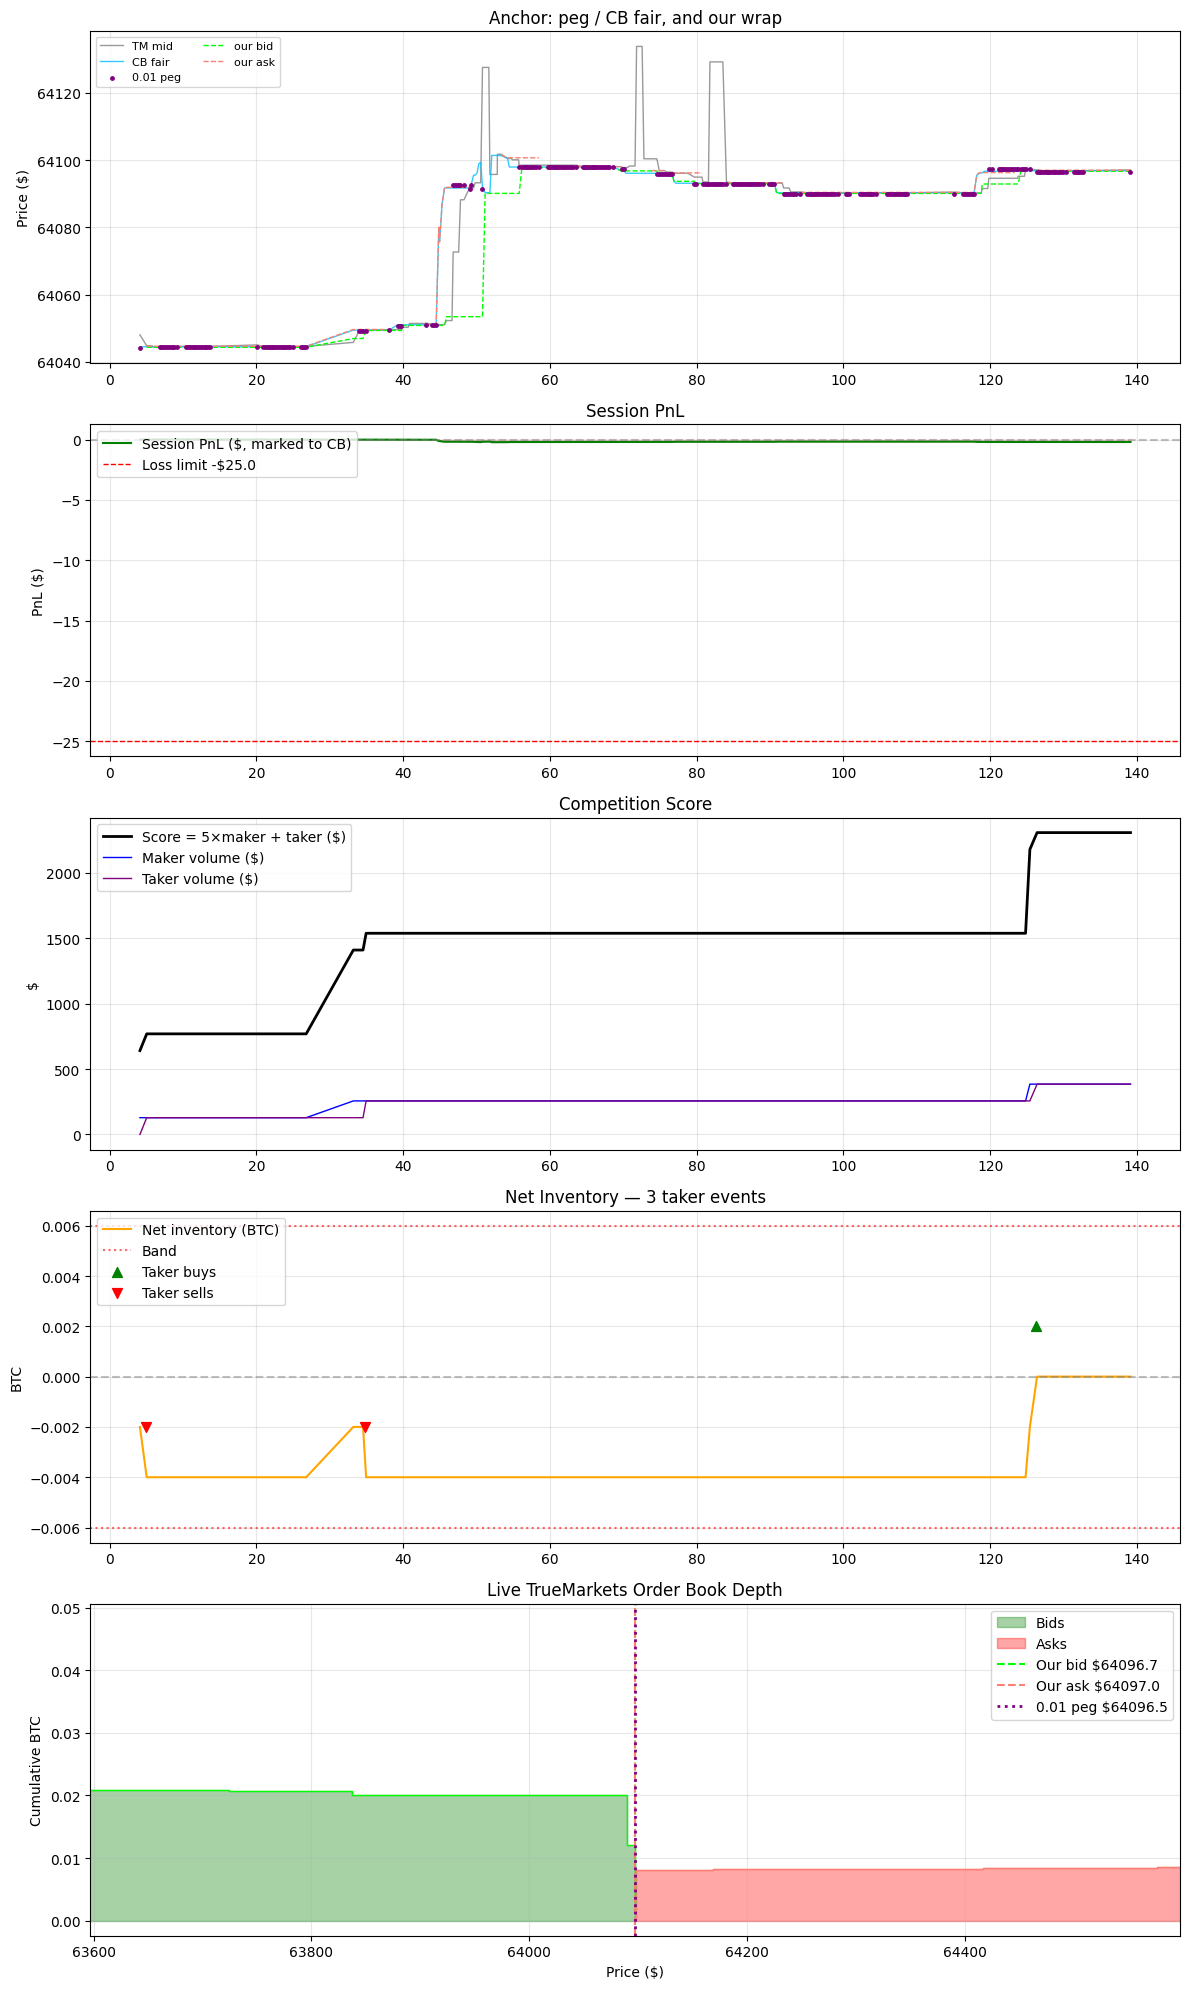

  00:21:30  tm 64096.7/64097.5  cb 64096.9  peg 64096.5(bid)  inv +0.0000  pnl $-0.204  score $2,306 (m $384/t $384)  fees ~$0.15  rl 72/100
    bid: BID 0.002 @ 64096.7 (wrap)  |  ask: ASK 0.002 @ 64097.0 (wrap)
  00:21:30  tm 64096.7/64097.0  cb 64096.9  peg 64096.5(bid)  inv +0.0000  pnl $-0.204  score $2,306 (m $384/t $384)  fees ~$0.15  rl 69/100
    bid: hold @ 64096.7 (wrap)  |  ask: hold @ 64097.0 (wrap)
  00:21:32  tm 64096.7/64097.0  cb 64096.9  peg 64096.5(bid)  inv +0.0000  pnl $-0.204  score $2,306 (m $384/t $384)  fees ~$0.15  rl 69/100
    bid: hold @ 64096.7 (wrap)  |  ask: hold @ 64097.0 (wrap)
  00:21:33  tm 64096.7/64097.0  cb 64096.9  peg 64096.5(bid)  inv +0.0000  pnl $-0.204  score $2,306 (m $384/t $384)  fees ~$0.15  rl 69/100
    bid: hold @ 64096.7 (wrap)  |  ask: hold @ 64097.0 (wrap)

Interrupted.
All orders cancelled on exit.
Stopped.


In [36]:
# Interrupt kernel (stop button) to exit cleanly — all orders are cancelled on the way out
await run_strategy()